In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

RAW = "../data/raw/42182099999.csv"

df = pd.read_csv(RAW, low_memory=False)

print("shape:", df.shape)
print("\ncolumns:")
print(df.columns.tolist())

shape: (2912, 31)

columns:
['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG', 'VIS', 'TMP', 'DEW', 'SLP', 'AA1', 'AY1', 'AY2', 'GA1', 'GA2', 'GA3', 'GE1', 'GF1', 'KA1', 'KA2', 'MA1', 'MD1', 'MW1', 'REM', 'EQD']


In [2]:
#df.head(10)
df[["STATION", "DATE", "REPORT_TYPE", "TMP", "DEW", "SLP"]].head(10)

,STATION,DATE,REPORT_TYPE,TMP,DEW,SLP
0,42182099999,2023-01-01T00:00:00,FM-12,"+0074,1","+0070,1","10199,1"
1,42182099999,2023-01-01T03:00:00,FM-12,"+0098,1","+0094,1","10219,1"
2,42182099999,2023-01-01T06:00:00,FM-12,"+0176,1","+0110,1","10223,1"
3,42182099999,2023-01-01T09:00:00,FM-12,"+0206,1","+0099,1","10190,1"
4,42182099999,2023-01-01T12:00:00,FM-12,"+0180,1","+0106,1","10189,1"
5,42182099999,2023-01-01T15:00:00,FM-12,"+0138,1","+0116,1","10210,1"
6,42182099999,2023-01-01T18:00:00,FM-12,"+0124,1","+0105,1","10216,1"
7,42182099999,2023-01-01T21:00:00,FM-12,"+0112,1","+0100,1","10209,1"
8,42182099999,2023-01-02T00:00:00,FM-12,"+0094,1","+0086,1","10208,1"
9,42182099999,2023-01-02T03:00:00,FM-12,"+0116,1","+0100,1","10227,1"


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2912 entries, 0 to 2911
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATION          2912 non-null   int64  
 1   DATE             2912 non-null   object 
 2   SOURCE           2912 non-null   int64  
 3   LATITUDE         2912 non-null   float64
 4   LONGITUDE        2912 non-null   float64
 5   ELEVATION        2912 non-null   float64
 6   NAME             2912 non-null   object 
 7   REPORT_TYPE      2912 non-null   object 
 8   CALL_SIGN        2912 non-null   int64  
 9   QUALITY_CONTROL  2912 non-null   object 
 10  WND              2912 non-null   object 
 11  CIG              2912 non-null   object 
 12  VIS              2912 non-null   object 
 13  TMP              2912 non-null   object 
 14  DEW              2912 non-null   object 
 15  SLP              2912 non-null   object 
 16  AA1              535 non-null    object 
 17  AY1           

,STATION,SOURCE,LATITUDE,LONGITUDE,ELEVATION,CALL_SIGN
count,2.912000e+03,2912.0,2912.000000,2912.000000,2.912000e+03,2912.0
mean,4.218210e+10,4.0,28.584511,77.205783,2.148800e+02,99999.0
std,0.000000e+00,0.0,0.000000,0.000000,5.685318e-14,0.0
min,4.218210e+10,4.0,28.584511,77.205783,2.148800e+02,99999.0
25%,4.218210e+10,4.0,28.584511,77.205783,2.148800e+02,99999.0
50%,4.218210e+10,4.0,28.584511,77.205783,2.148800e+02,99999.0
75%,4.218210e+10,4.0,28.584511,77.205783,2.148800e+02,99999.0
max,4.218210e+10,4.0,28.584511,77.205783,2.148800e+02,99999.0


In [4]:
def parse_isd(col, missing):
    """Split an ISD 'value,quality' field into a scaled float and its QC code."""
    parts = col.astype(str).str.split(",", expand=True)
    value = pd.to_numeric(parts[0], errors="coerce")
    value = value.where(value != missing) / 10.0
    qc = parts[1]
    return value, qc

d = pd.DataFrame()
d["time"]    = pd.to_datetime(df["DATE"])
d["station"] = df["STATION"].astype(str)
d["report"]  = df["REPORT_TYPE"].astype(str).str.strip()

d["temp_c"],  d["temp_qc"] = parse_isd(df["TMP"], 9999)
d["dew_c"],   d["dew_qc"]  = parse_isd(df["DEW"], 9999)
d["slp_hpa"], d["slp_qc"]  = parse_isd(df["SLP"], 99999)

d.head()

,time,station,report,temp_c,temp_qc,dew_c,dew_qc,slp_hpa,slp_qc
0,2023-01-01 00:00:00,42182099999,FM-12,7.4,1,7.0,1,1019.9,1
1,2023-01-01 03:00:00,42182099999,FM-12,9.8,1,9.4,1,1021.9,1
2,2023-01-01 06:00:00,42182099999,FM-12,17.6,1,11.0,1,1022.3,1
3,2023-01-01 09:00:00,42182099999,FM-12,20.6,1,9.9,1,1019.0,1
4,2023-01-01 12:00:00,42182099999,FM-12,18.0,1,10.6,1,1018.9,1


In [5]:
A, B = 17.625, 243.04

d["rh_pct"] = 100 * np.exp(
    (A * d["dew_c"]) / (B + d["dew_c"]) - (A * d["temp_c"]) / (B + d["temp_c"])
)

d["rh_pct"] = d["rh_pct"].clip(upper=100)

print(d[["temp_c", "dew_c", "rh_pct"]].describe())

            temp_c        dew_c       rh_pct
count  2910.000000  2910.000000  2909.000000
mean     24.776048    18.207629    70.763499
std       7.739634     6.136720    20.505360
min       4.200000    -1.300000    14.836686
25%      19.200000    14.000000    54.910601
50%      26.400000    17.800000    73.585141
75%      30.600000    24.100000    88.374267
max      42.600000    29.400000   100.000000


In [6]:
cols = ["temp_c", "slp_hpa", "rh_pct"]

print("rows:", len(d))
print("time range:", d["time"].min(), "→", d["time"].max())
print("station id(s):", d["station"].unique())

print("\n--- missing counts ---")
print(d[cols].isna().sum())

print("\n--- missing percentage ---")
print((d[cols].isna().mean() * 100).round(2))

print("\n--- rows per report type ---")
print(d["report"].value_counts())

print("\n--- temperature quality codes ---")
print(d["temp_qc"].value_counts(dropna=False))

print("\n--- pressure quality codes ---")
print(d["slp_qc"].value_counts(dropna=False))

print("\n--- duplicate timestamps ---")
print(d["time"].duplicated().sum())

rows: 2912
time range: 2023-01-01 00:00:00 → 2023-12-31 21:00:00
station id(s): ['42182099999']

--- missing counts ---
temp_c      2
slp_hpa    54
rh_pct      3
dtype: int64

--- missing percentage ---
temp_c     0.07
slp_hpa    1.85
rh_pct     0.10
dtype: float64

--- rows per report type ---
report
FM-12    2861
FM-15      51
Name: count, dtype: int64

--- temperature quality codes ---
temp_qc
1    2879
2      29
9       2
5       2
Name: count, dtype: int64

--- pressure quality codes ---
slp_qc
1    2855
9      54
2       3
Name: count, dtype: int64

--- duplicate timestamps ---
19


In [7]:
main_type = d["report"].value_counts().idxmax()
print("most common report type:", main_type)

p = d[d["report"] == main_type].copy()
p = p.sort_values("time").reset_index(drop=True)
p = p.drop_duplicates(subset="time", keep="first").reset_index(drop=True)

p = p[["time", "station", "temp_c", "temp_qc",
       "dew_c", "dew_qc", "slp_hpa", "slp_qc", "rh_pct"]]

print("rows after filtering:", len(p))
print(p.dtypes)
p.head()

most common report type: FM-12
rows after filtering: 2861
time       datetime64[ns]
station            object
temp_c            float64
temp_qc            object
dew_c             float64
dew_qc             object
slp_hpa           float64
slp_qc             object
rh_pct            float64
dtype: object


,time,station,temp_c,temp_qc,dew_c,dew_qc,slp_hpa,slp_qc,rh_pct
0,2023-01-01 00:00:00,42182099999,7.4,1,7.0,1,1019.9,1,97.300859
1,2023-01-01 03:00:00,42182099999,9.8,1,9.4,1,1021.9,1,97.351215
2,2023-01-01 06:00:00,42182099999,17.6,1,11.0,1,1022.3,1,65.247653
3,2023-01-01 09:00:00,42182099999,20.6,1,9.9,1,1019.0,1,50.291982
4,2023-01-01 12:00:00,42182099999,18.0,1,10.6,1,1018.9,1,61.955393


## Coverage and Gaps


In [8]:
p["gap_hours"] = p["time"].diff().dt.total_seconds() / 3600

print("--- most common intervals (hours) ---")
print(p["gap_hours"].value_counts().head(10))

print("\n--- interval statistics ---")
print(p["gap_hours"].describe())

median_gap = p["gap_hours"].median()
print("\nnominal sampling interval: %.2f hours" % median_gap)

span_hours = (p["time"].max() - p["time"].min()).total_seconds() / 3600
expected = span_hours / median_gap
print("observations present : %d" % len(p))
print("observations expected: %d" % expected)
print("coverage             : %.1f%%" % (100 * len(p) / expected))

gaps = p.loc[p["gap_hours"] > 2 * median_gap, ["time", "gap_hours"]].copy()
gaps["gap_start"] = gaps["time"] - pd.to_timedelta(gaps["gap_hours"], unit="h")
gaps = gaps.rename(columns={"time": "resumed_at"})
print("\n--- missing-data blocks (%d found) ---" % len(gaps))
print(gaps.sort_values("gap_hours", ascending=False).head(15))

--- most common intervals (hours) ---
gap_hours
3.0     2819
6.0       37
12.0       3
42.0       1
Name: count, dtype: int64

--- interval statistics ---
count    2860.000000
mean        3.061888
std         0.854191
min         3.000000
25%         3.000000
50%         3.000000
75%         3.000000
max        42.000000
Name: gap_hours, dtype: float64

nominal sampling interval: 3.00 hours
observations present : 2861
observations expected: 2919
coverage             : 98.0%

--- missing-data blocks (4 found) ---
              resumed_at  gap_hours           gap_start
2818 2023-12-26 12:00:00       42.0 2023-12-24 18:00:00
485  2023-03-03 09:00:00       12.0 2023-03-02 21:00:00
2068 2023-09-20 00:00:00       12.0 2023-09-19 12:00:00
2135 2023-09-28 18:00:00       12.0 2023-09-28 06:00:00


In [9]:
frac = p["temp_c"].dropna().mod(1)
print("fractional parts of temperature values:")
print(frac.value_counts().head(10))
print("\ndistinct temperature values:", p["temp_c"].nunique())

fractional parts of temperature values:
temp_c
0.0    573
0.4    505
0.2    467
0.6    462
0.8    403
0.2    126
0.6    103
0.4    103
0.8     87
0.8      9
Name: count, dtype: int64

distinct temperature values: 201


In [10]:
tenths = (p["temp_c"].dropna() * 10).round().mod(10)
print(tenths.value_counts())

temp_c
4.0    608
2.0    599
0.0    573
6.0    565
8.0    499
7.0      8
5.0      7
Name: count, dtype: int64


In [11]:
def timeplot(x, y, title, ylabel, color, outfile):
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(x, y, lw=0.5, color=color)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Date (UTC)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    fig.autofmt_xdate(rotation=45)

    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()

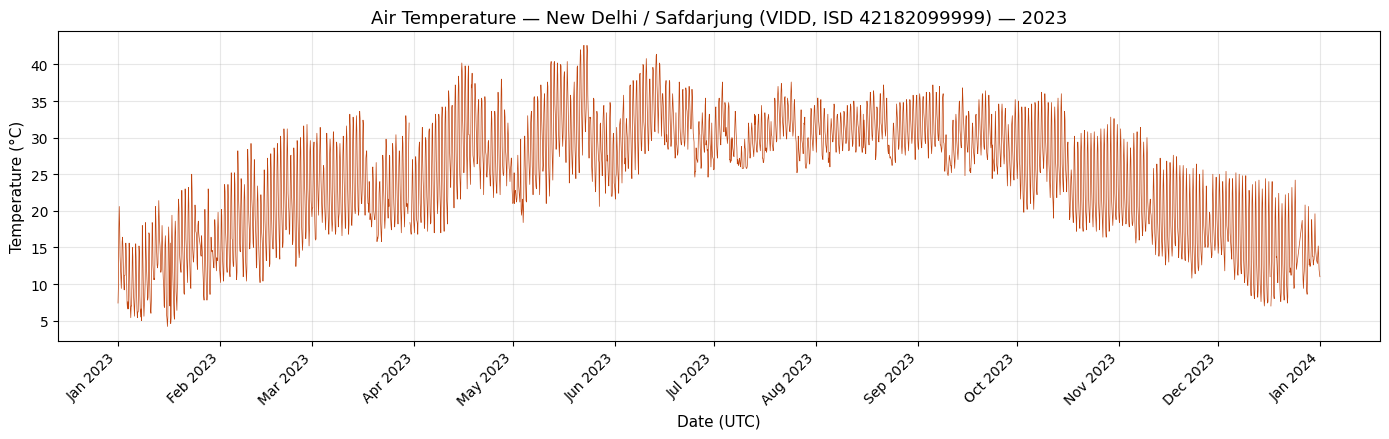

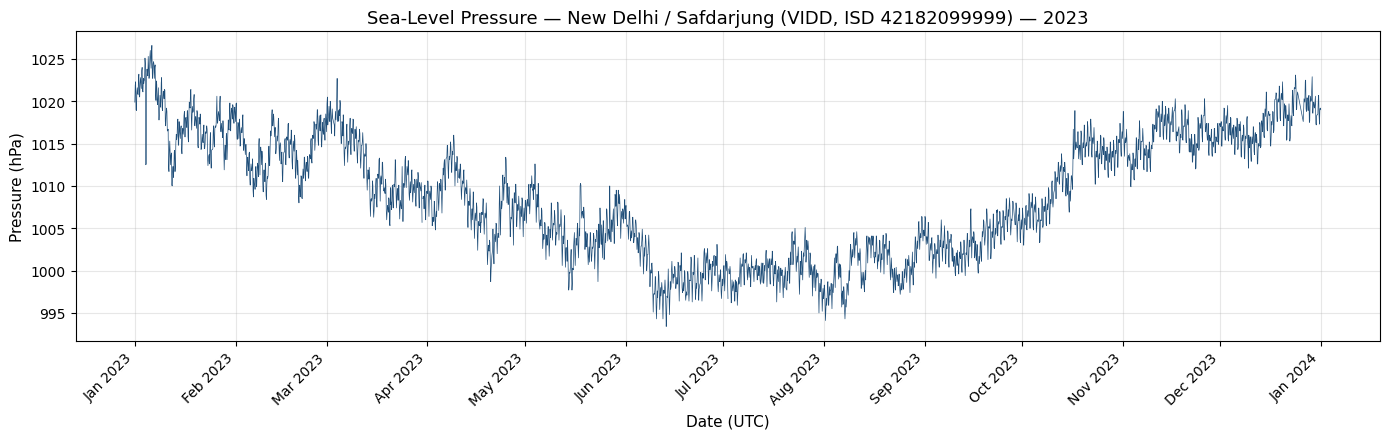

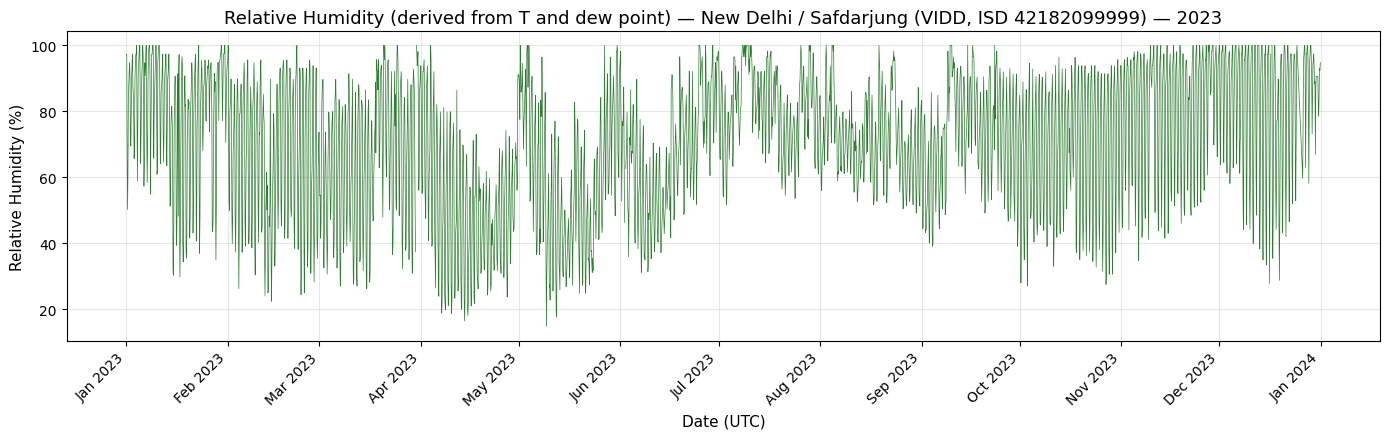

In [12]:
STATION_LABEL = "New Delhi / Safdarjung (VIDD, ISD 42182099999) — 2023"

timeplot(p["time"], p["temp_c"],
         "Air Temperature — " + STATION_LABEL,
         "Temperature (°C)", "#c1440e",
         "../figures/01_temperature.png")

timeplot(p["time"], p["slp_hpa"],
         "Sea-Level Pressure — " + STATION_LABEL,
         "Pressure (hPa)", "#1f4e79",
         "../figures/02_pressure.png")

timeplot(p["time"], p["rh_pct"],
         "Relative Humidity (derived from T and dew point) — " + STATION_LABEL,
         "Relative Humidity (%)", "#2e7d32",
         "../figures/03_humidity.png")

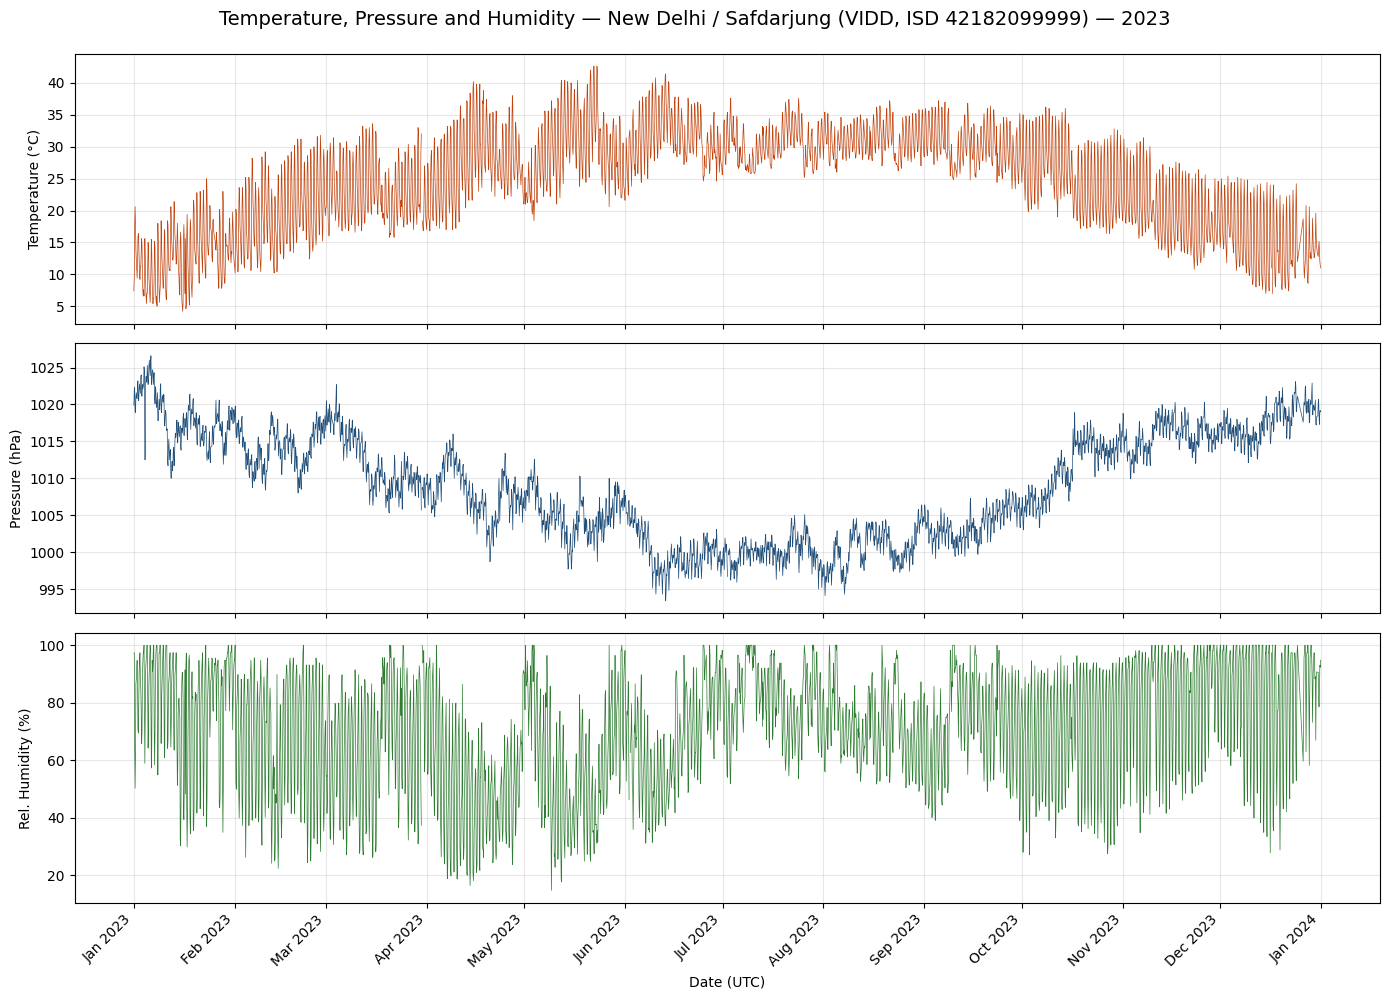

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax[0].plot(p["time"], p["temp_c"], lw=0.5, color="#c1440e")
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid(alpha=0.3)

ax[1].plot(p["time"], p["slp_hpa"], lw=0.5, color="#1f4e79")
ax[1].set_ylabel("Pressure (hPa)")
ax[1].grid(alpha=0.3)

ax[2].plot(p["time"], p["rh_pct"], lw=0.5, color="#2e7d32")
ax[2].set_ylabel("Rel. Humidity (%)")
ax[2].set_xlabel("Date (UTC)")
ax[2].grid(alpha=0.3)

ax[2].xaxis.set_major_locator(mdates.MonthLocator())
ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=45)

fig.suptitle("Temperature, Pressure and Humidity — " + STATION_LABEL,
             fontsize=14, y=0.995)
fig.tight_layout()
fig.savefig("../figures/04_combined.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
cols = ["temp_c", "slp_hpa", "rh_pct"]

stats = p[cols].agg(["min", "max", "mean", "median", "std"]).T.round(2)
stats["missing_pct"] = (p[cols].isna().mean() * 100).round(2)
stats["n_valid"] = p[cols].notna().sum()

print(stats)
stats.to_csv("../data/processed/summary_stats.csv")

            min     max     mean   median    std  missing_pct  n_valid
temp_c     4.20    42.6    24.74    26.20   7.77         0.07     2859
slp_hpa  993.40  1026.6  1008.80  1008.50   7.19         0.10     2858
rh_pct    14.84   100.0    70.94    73.73  20.53         0.10     2858


In [15]:
for c, label in [("temp_c", "Temperature"), ("slp_hpa", "Pressure"), ("rh_pct", "Humidity")]:
    p[c + "_step"] = p[c].diff()

    print("\n=== %s: 10 largest changes between consecutive readings ===" % label)
    top = p.reindex(p[c + "_step"].abs().sort_values(ascending=False).index).head(10)
    print(top[["time", c, c + "_step", "gap_hours"]].to_string(index=False))


=== Temperature: 10 largest changes between consecutive readings ===
               time  temp_c  temp_c_step  gap_hours
2023-12-17 06:00:00    22.0         13.4        3.0
2023-12-15 06:00:00    21.0         13.2        3.0
2023-04-15 06:00:00    38.8         13.2        3.0
2023-12-16 06:00:00    20.5         12.9        3.0
2023-02-06 06:00:00    24.4         12.8        3.0
2023-03-02 06:00:00    28.8         12.6        3.0
2023-03-12 06:00:00    30.6         12.4        3.0
2023-02-25 06:00:00    26.8         12.4        3.0
2023-02-20 06:00:00    28.2         12.4        3.0
2023-05-30 18:00:00    22.0        -12.2        6.0

=== Pressure: 10 largest changes between consecutive readings ===
               time  slp_hpa  slp_hpa_step  gap_hours
2023-01-04 09:00:00   1012.5         -11.9        3.0
2023-01-04 15:00:00   1023.0          10.4        3.0
2023-05-27 03:00:00   1010.0           6.3        3.0
2023-05-18 00:00:00   1010.0           5.9        3.0
2023-05-28 18:00:00  

In [16]:
def find_flat_runs(frame, col, min_len=8):
    s = frame[col]
    run_id = s.ne(s.shift()).cumsum()
    g = frame.assign(_run=run_id).groupby("_run")
    runs = g.agg(start=("time", "min"),
                 end=("time", "max"),
                 length=("time", "size"),
                 value=(col, "first"))
    runs = runs[(runs["length"] >= min_len) & runs["value"].notna()]
    return runs.sort_values("length", ascending=False)

for c, label in [("temp_c", "Temperature"), ("slp_hpa", "Pressure"), ("rh_pct", "Humidity")]:
    r = find_flat_runs(p, c, min_len=8)
    print("\n=== %s: constant runs of 8+ consecutive readings (%d found) ===" % (label, len(r)))
    print(r.head(10).to_string())


=== Temperature: constant runs of 8+ consecutive readings (0 found) ===
Empty DataFrame
Columns: [start, end, length, value]
Index: []

=== Pressure: constant runs of 8+ consecutive readings (0 found) ===
Empty DataFrame
Columns: [start, end, length, value]
Index: []

=== Humidity: constant runs of 8+ consecutive readings (0 found) ===
Empty DataFrame
Columns: [start, end, length, value]
Index: []


In [17]:
candidates = []

for c in cols:
    r = find_flat_runs(p, c, min_len=8)
    for _, row in r.head(5).iterrows():
        candidates.append({"variable": c, "type": "flat_run",
                           "start": row["start"], "end": row["end"],
                           "detail": "%d constant readings at %.1f" % (row["length"], row["value"])})

for _, row in gaps.sort_values("gap_hours", ascending=False).head(5).iterrows():
    candidates.append({"variable": "all", "type": "missing_block",
                       "start": row["gap_start"], "end": row["resumed_at"],
                       "detail": "%.1f hour gap" % row["gap_hours"]})

for c in cols:
    top = p.reindex(p[c + "_step"].abs().sort_values(ascending=False).index).head(3)
    for _, row in top.iterrows():
        candidates.append({"variable": c, "type": "step",
                           "start": row["time"], "end": row["time"],
                           "detail": "change of %.1f in %.1f h" % (row[c + "_step"], row["gap_hours"])})

cand = pd.DataFrame(candidates).sort_values("start").reset_index(drop=True)
cand.to_csv("../data/processed/candidate_periods.csv", index=False)
print(cand.to_string())

   variable           type               start                 end                    detail
0   slp_hpa           step 2023-01-04 09:00:00 2023-01-04 09:00:00  change of -11.9 in 3.0 h
1   slp_hpa           step 2023-01-04 15:00:00 2023-01-04 15:00:00   change of 10.4 in 3.0 h
2       all  missing_block 2023-03-02 21:00:00 2023-03-03 09:00:00             12.0 hour gap
3    rh_pct           step 2023-03-29 15:00:00 2023-03-29 15:00:00   change of 54.4 in 3.0 h
4    temp_c           step 2023-04-15 06:00:00 2023-04-15 06:00:00   change of 13.2 in 3.0 h
5   slp_hpa           step 2023-05-27 03:00:00 2023-05-27 03:00:00    change of 6.3 in 3.0 h
6       all  missing_block 2023-09-19 12:00:00 2023-09-20 00:00:00             12.0 hour gap
7       all  missing_block 2023-09-28 06:00:00 2023-09-28 18:00:00             12.0 hour gap
8    rh_pct           step 2023-12-14 06:00:00 2023-12-14 06:00:00  change of -56.5 in 3.0 h
9    temp_c           step 2023-12-15 06:00:00 2023-12-15 06:00:00   c

In [18]:
p.to_csv("../data/processed/vidd_2023_clean.csv", index=False)
print("saved", len(p), "rows")
print(p.columns.tolist())

saved 2861 rows
['time', 'station', 'temp_c', 'temp_qc', 'dew_c', 'dew_qc', 'slp_hpa', 'slp_qc', 'rh_pct', 'gap_hours', 'temp_c_step', 'slp_hpa_step', 'rh_pct_step']
